# Graphing Analysis

This notebook creates visualizations for the MCSLC and SPD project.

The goal of this notebook is to:

- Load the cleaned datasets created in `updated_cleaned_data.ipynb`
- Graph MCSLC response times
- Compare response times before and after the August 2024 rollout
- Graph monthly response time trends
- Graph dispatch reasons
- Graph dispositions
- Graph endpoints of dispatch
- Graph relevant SPD call types
- Save graph images for use in the final report or GitHub README

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

## 1. Set File Paths

This section sets the folder path for the cleaned data and the folder where visualizations will be saved.

Because this project is currently being run in Jupyter, this notebook is in the same folder as the notebook as the cleaned CSV files.

In [74]:
# Use the same folder as the current Jupyter notebook
DATA_FOLDER = Path(".")

# Folder for saved visualizations
VISUALS_FOLDER = Path("visualizations")
VISUALS_FOLDER.mkdir(parents=True, exist_ok=True)

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir(DATA_FOLDER))

Current working directory:
C:\Users\Phoenix M\DSiA Project

Files in this folder:
['.ipynb_checkpoints', '2015-2025 SPD Calls for Service.csv', '2015-2025 SPD Calls with Close Codes.csv', '2015-2025 SPD Responding Units.csv', 'cleaned_mcslc.csv', 'cleaned_mcslc_reasons_long.csv', 'cleaned_spd_calls.csv', 'cleaned_spd_close_codes.csv', 'cleaned_spd_relevant_calls.csv', 'cleaned_spd_units.csv', 'Clean_data.ipynb', 'data', 'Eugene_CAD_data_noloc - Copy', 'Graphing_Analysis.ipynb', 'graph_boxplot_Minutes_Arrival_to_Engagement.png', 'graph_boxplot_Minutes_Dispatch_to_Arrival.png', 'graph_boxplot_Minutes_Request_to_Dispatch.png', 'graph_dispatch_endpoints_before_after.png', 'graph_dispatch_reason_categories_before_after.png', 'graph_dispatch_reason_percentages_before_after.png', 'graph_dispositions_before_after.png', 'graph_mean_bar_Minutes_Request_to_Dispatch.png', 'graph_mean_Minutes_Arrival_to_Departure_by_city_period.png', 'graph_mean_Minutes_Arrival_to_Departure_by_period.png', 'graph_m

## 2. Load Cleaned Data

This function loads the cleaned files created by the cleaning notebook.
Before running this notebook, make sure you already ran `updated_cleaned_data.ipynb`.

In [75]:
def load_cleaned_data(data_folder=DATA_FOLDER):
    """
    Loads cleaned project datasets created by updated_cleaned_data.ipynb.
    """
    mcslc_clean = pd.read_csv(data_folder / "mcslc_clean.csv")
    reasons_long_clean = pd.read_csv(data_folder / "reasons_long_clean.csv")
    spd_calls_clean = pd.read_csv(data_folder / "spd_calls_clean.csv")
    spd_relevant = pd.read_csv(data_folder / "spd_relevant_calls_clean.csv")
    spd_close_codes_clean = pd.read_csv(data_folder / "spd_close_codes_clean.csv")
    spd_units_clean = pd.read_csv(data_folder / "spd_units_clean.csv")
    
    return (
        mcslc_clean,
        reasons_long_clean,
        spd_calls_clean,
        spd_relevant,
        spd_close_codes_clean,
        spd_units_clean
    )

## 3. Load the Cleaned Datasets

This cell calls the loading function and checks the shape of each dataset.

In [76]:
(
    mcslc_clean,
    reasons_long_clean,
    spd_calls_clean,
    spd_relevant,
    spd_close_codes_clean,
    spd_units_clean
) = load_cleaned_data()

print("MCSLC cleaned shape:", mcslc_clean.shape)
print("Reasons long shape:", reasons_long_clean.shape)
print("SPD calls cleaned shape:", spd_calls_clean.shape)
print("SPD relevant calls shape:", spd_relevant.shape)
print("SPD close codes cleaned shape:", spd_close_codes_clean.shape)
print("SPD units cleaned shape:", spd_units_clean.shape)

MCSLC cleaned shape: (4682, 21)
Reasons long shape: (9185, 9)
SPD calls cleaned shape: (54804, 11)
SPD relevant calls shape: (7288, 11)
SPD close codes cleaned shape: (98, 2)
SPD units cleaned shape: (56, 6)


## 4. Convert Date Columns

Some date columns may reload from CSV as text, so this section converts them back into datetime format.

In [77]:
# Convert MCSLC date/time columns back to datetime after loading from CSV
mcslc_datetime_cols = [
    "dispatch_request_date_and_time",
    "dispatch_date_and_time",
    "arrival_on_scene_date_and_time",
    "engagement_with_client_date_and_time",
    "mcit_departure_date_and_time"
]

for col in mcslc_datetime_cols:
    if col in mcslc_clean.columns:
        mcslc_clean[col] = pd.to_datetime(mcslc_clean[col], errors="coerce")

if "dispatch_request_date_and_time" in reasons_long_clean.columns:
    reasons_long_clean["dispatch_request_date_and_time"] = pd.to_datetime(
        reasons_long_clean["dispatch_request_date_and_time"],
        errors="coerce")

## 5. Set Main Response Time Columns

These are the response time variables used in the project graphs.

In [78]:
response_time_cols = [
    "minutes_request_to_dispatch",
    "minutes_dispatch_to_arrival",
    "minutes_arrival_to_engagement",
    "minutes_arrival_to_departure"
]

response_time_cols = [
    col for col in response_time_cols
    if col in mcslc_clean.columns
]

response_time_cols

['minutes_request_to_dispatch',
 'minutes_dispatch_to_arrival',
 'minutes_arrival_to_engagement',
 'minutes_arrival_to_departure']

## 6. Helper Function for Saving Graphs

This helper function saves each graph to the `visualizations` folder.

In [79]:
def save_graph(filename):
    """
    Saves the current matplotlib graph to the visualizations folder.
    """
    plt.tight_layout()
    plt.savefig(VISUALS_FOLDER / filename, dpi=300, bbox_inches="tight")
    plt.show()

## 7. Average Response Times by Stage

This graph compares the average time for each stage of the MCSLC response pipeline.

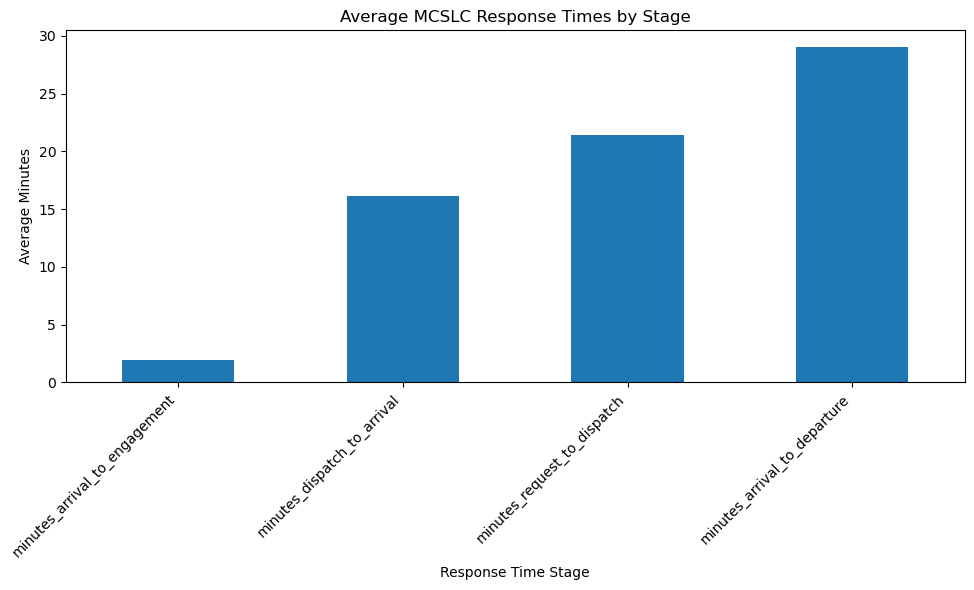

In [80]:
avg_response_times = mcslc_clean[response_time_cols].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_response_times.plot(kind="bar")
plt.title("Average MCSLC Response Times by Stage")
plt.xlabel("Response Time Stage")
plt.ylabel("Average Minutes")
plt.xticks(rotation=45, ha="right")
save_graph("average_response_times_by_stage.png")

## 8. Median Response Times by Stage

This graph compares the median time for each stage of the MCSLC response pipeline.

Median is useful because response time data can be affected by extreme outliers.

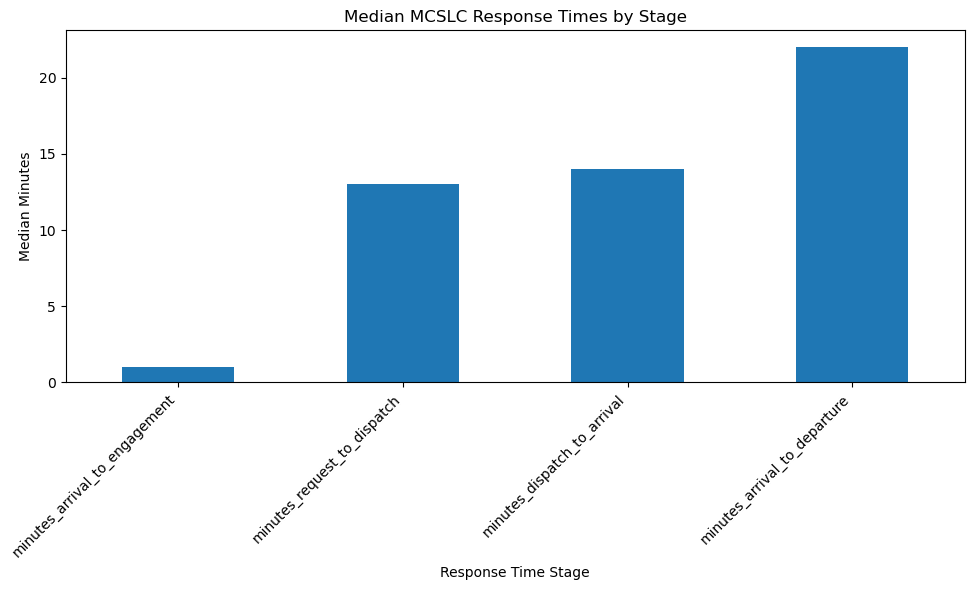

In [81]:
median_response_times = mcslc_clean[response_time_cols].median().sort_values()

plt.figure(figsize=(10, 6))
median_response_times.plot(kind="bar")
plt.title("Median MCSLC Response Times by Stage")
plt.xlabel("Response Time Stage")
plt.ylabel("Median Minutes")
plt.xticks(rotation=45, ha="right")
save_graph("median_response_times_by_stage.png")

## 9. Average Response Times Before vs. After Rollout

This graph compares average response times before and after the August 2024 rollout.

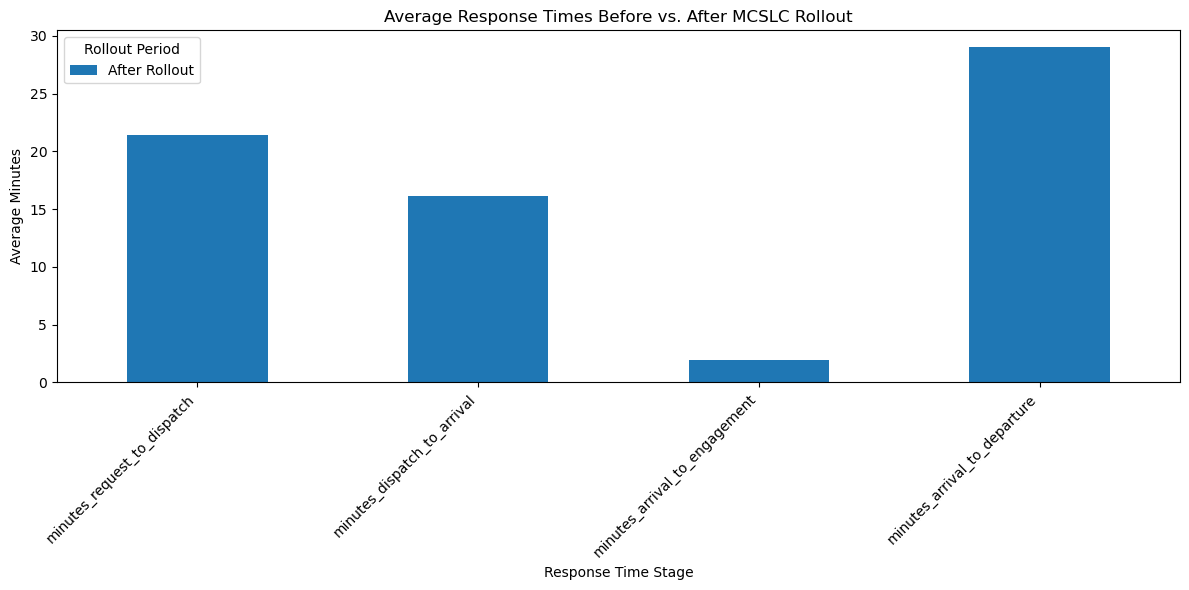

In [82]:
if "rollout_period" in mcslc_clean.columns:
    rollout_means = (
        mcslc_clean
        .groupby("rollout_period")[response_time_cols]
        .mean()
    )
    
    rollout_means.T.plot(kind="bar", figsize=(12, 6))
    plt.title("Average Response Times Before vs. After MCSLC Rollout")
    plt.xlabel("Response Time Stage")
    plt.ylabel("Average Minutes")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Rollout Period")
    save_graph("average_response_times_before_after_rollout.png")
else:
    print("rollout_period column not found.")

## 10. Median Response Times Before vs. After Rollout

This graph compares median response times before and after the August 2024 rollout.

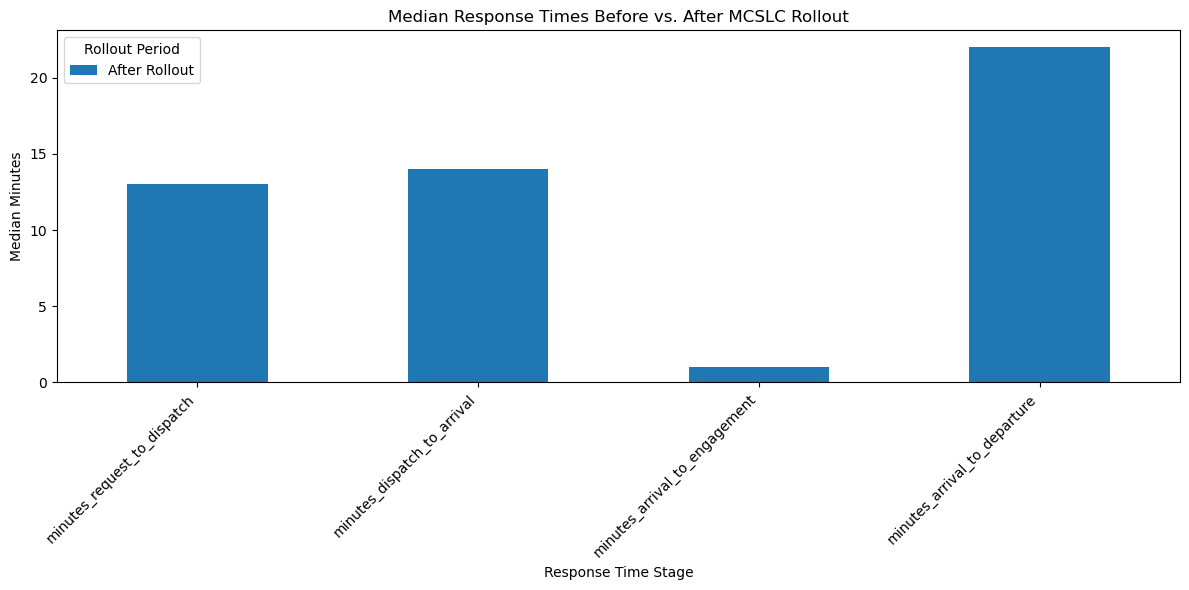

In [83]:
if "rollout_period" in mcslc_clean.columns:
    rollout_medians = (
        mcslc_clean
        .groupby("rollout_period")[response_time_cols]
        .median()
    )
    
    rollout_medians.T.plot(kind="bar", figsize=(12, 6))
    plt.title("Median Response Times Before vs. After MCSLC Rollout")
    plt.xlabel("Response Time Stage")
    plt.ylabel("Median Minutes")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Rollout Period")
    save_graph("median_response_times_before_after_rollout.png")
else:
    print("rollout_period column not found.")

## 11. Monthly Average Response Time Trends

This graph shows how average response times changed across months.

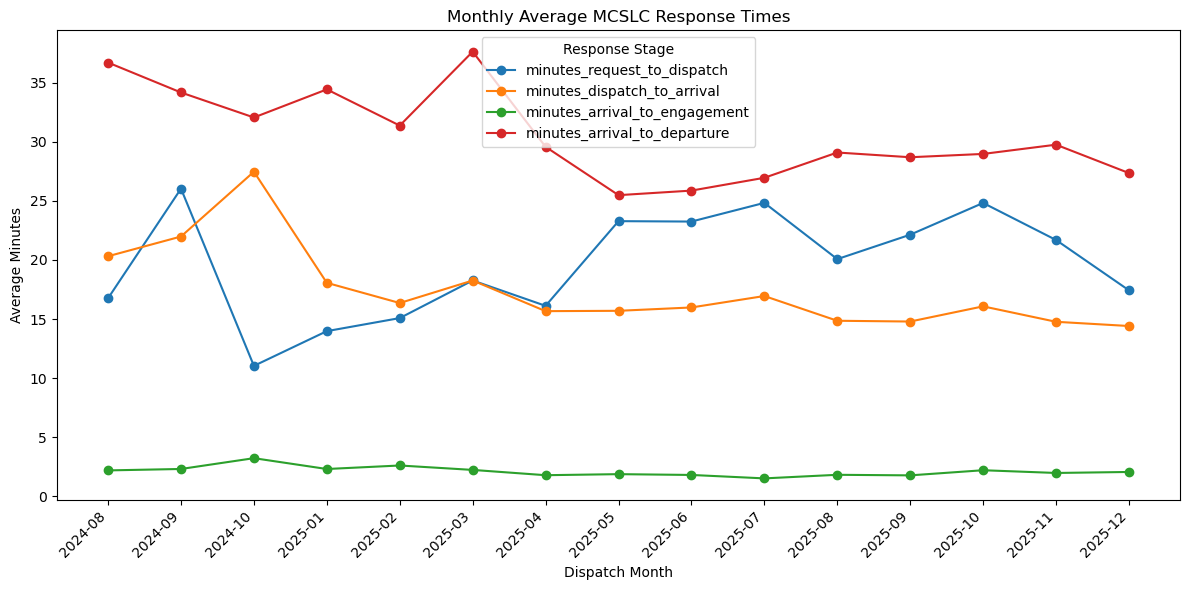

In [84]:
if "dispatch_month" in mcslc_clean.columns:
    monthly_response = (
        mcslc_clean
        .groupby("dispatch_month")[response_time_cols]
        .mean()
        .reset_index()
    )
    
    monthly_response = monthly_response.sort_values("dispatch_month")
    
    plt.figure(figsize=(12, 6))
    
    for col in response_time_cols:
        plt.plot(
            monthly_response["dispatch_month"],
            monthly_response[col],
            marker="o",
            label=col
        )
    
    plt.title("Monthly Average MCSLC Response Times")
    plt.xlabel("Dispatch Month")
    plt.ylabel("Average Minutes")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Response Stage")
    save_graph("monthly_average_response_times.png")
else:
    print("dispatch_month column not found.")

## 12. Monthly Median Response Time Trends

This graph shows monthly median response times, which helps reduce the effect of outliers.

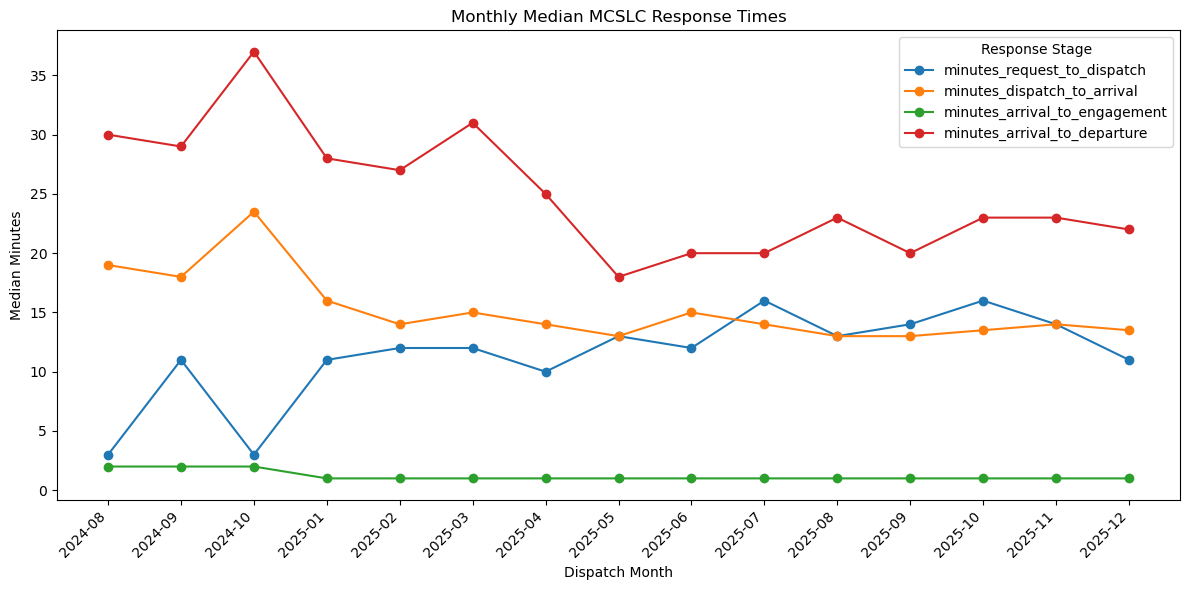

In [85]:
if "dispatch_month" in mcslc_clean.columns:
    monthly_response_median = (
        mcslc_clean
        .groupby("dispatch_month")[response_time_cols]
        .median()
        .reset_index()
    )
    
    monthly_response_median = monthly_response_median.sort_values("dispatch_month")
    
    plt.figure(figsize=(12, 6))
    
    for col in response_time_cols:
        plt.plot(
            monthly_response_median["dispatch_month"],
            monthly_response_median[col],
            marker="o",
            label=col
        )
    
    plt.title("Monthly Median MCSLC Response Times")
    plt.xlabel("Dispatch Month")
    plt.ylabel("Median Minutes")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Response Stage")
    save_graph("monthly_median_response_times.png")
else:
    print("dispatch_month column not found.")

## 13. Response Time Boxplot by Rollout Period

This graph shows the spread of response times before and after rollout.

Boxplots are useful because they show variation and outliers.

C:\Users\Phoenix M\AppData\Local\Temp\ipykernel_50048\2090811957.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


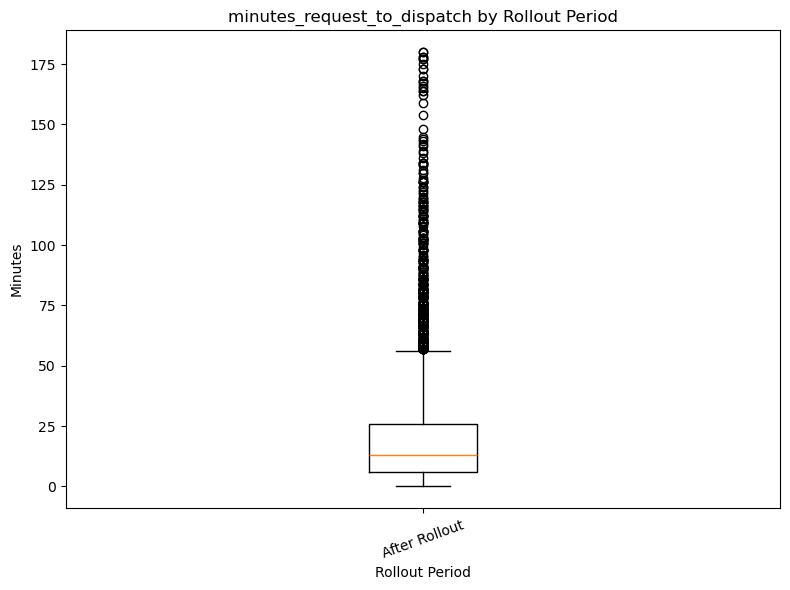

C:\Users\Phoenix M\AppData\Local\Temp\ipykernel_50048\2090811957.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


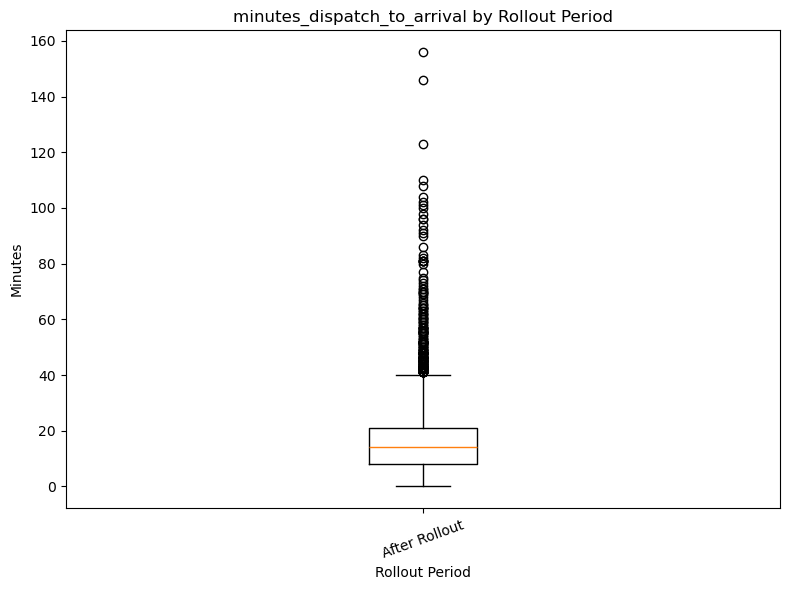

C:\Users\Phoenix M\AppData\Local\Temp\ipykernel_50048\2090811957.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


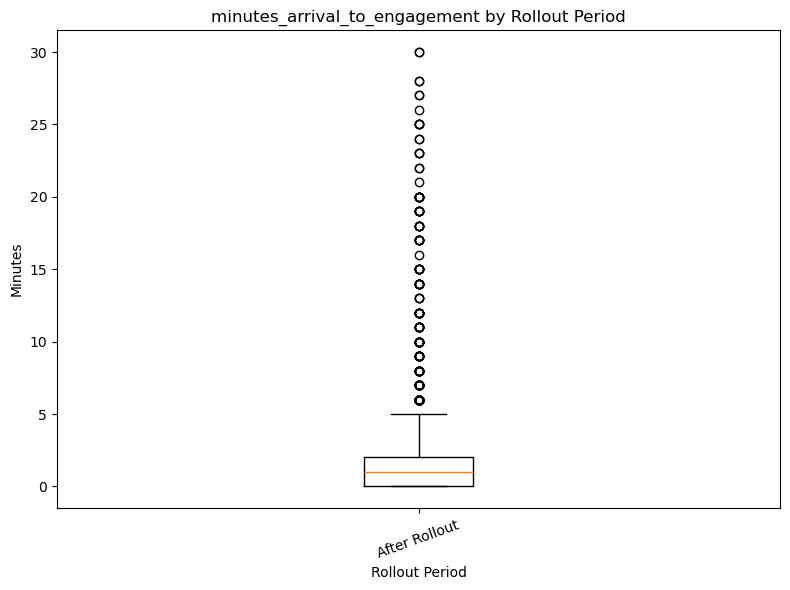

C:\Users\Phoenix M\AppData\Local\Temp\ipykernel_50048\2090811957.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


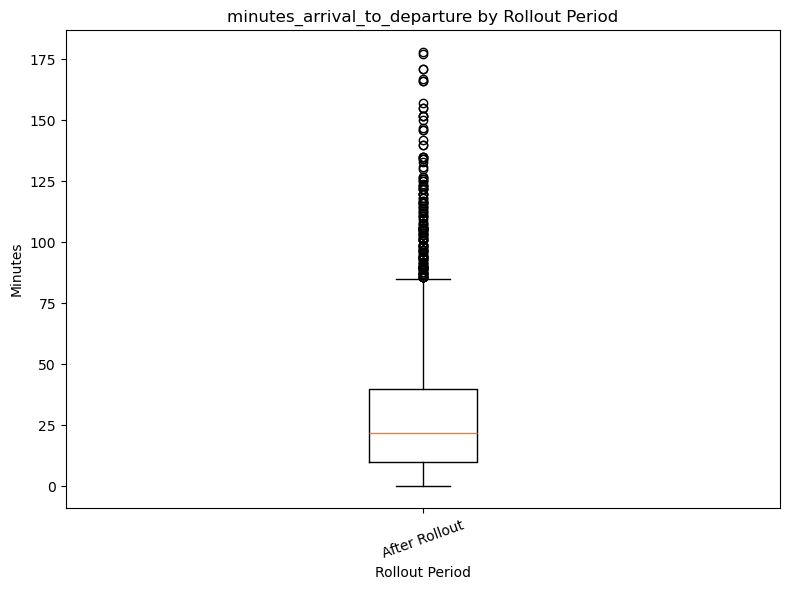

In [86]:
if "rollout_period" in mcslc_clean.columns and len(response_time_cols) > 0:
    for col in response_time_cols:
        data_to_plot = [
            mcslc_clean.loc[mcslc_clean["rollout_period"] == period, col].dropna()
            for period in mcslc_clean["rollout_period"].dropna().unique()
        ]
        
        labels = mcslc_clean["rollout_period"].dropna().unique()
        
        plt.figure(figsize=(8, 6))
        plt.boxplot(data_to_plot, labels=labels)
        plt.title(f"{col} by Rollout Period")
        plt.xlabel("Rollout Period")
        plt.ylabel("Minutes")
        plt.xticks(rotation=20)
        save_graph(f"{col}_boxplot_by_rollout_period.png")
else:
    print("rollout_period column or response time columns not found.")

## 14. Top Dispatch Reasons

This graph shows the most common reasons for MCSLC dispatch.

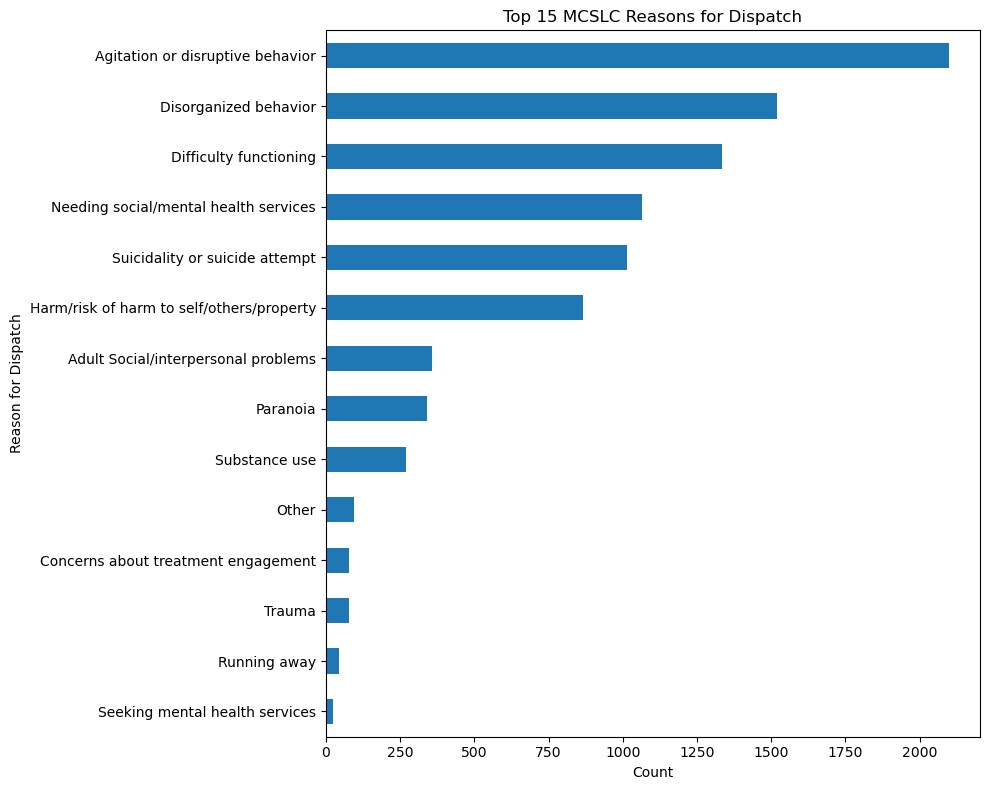

In [87]:
if "reason_for_dispatch" in reasons_long_clean.columns:
    top_reasons = (
        reasons_long_clean["reason_for_dispatch"]
        .value_counts()
        .head(15)
        .sort_values()
    )
    
    plt.figure(figsize=(10, 8))
    top_reasons.plot(kind="barh")
    plt.title("Top 15 MCSLC Reasons for Dispatch")
    plt.xlabel("Count")
    plt.ylabel("Reason for Dispatch")
    save_graph("top_15_reasons_for_dispatch.png")
else:
    print("reason_for_dispatch column not found.")

## 15. Top Dispatch Reasons by Rollout Period

This graph compares the most common reasons for dispatch before and after rollout.

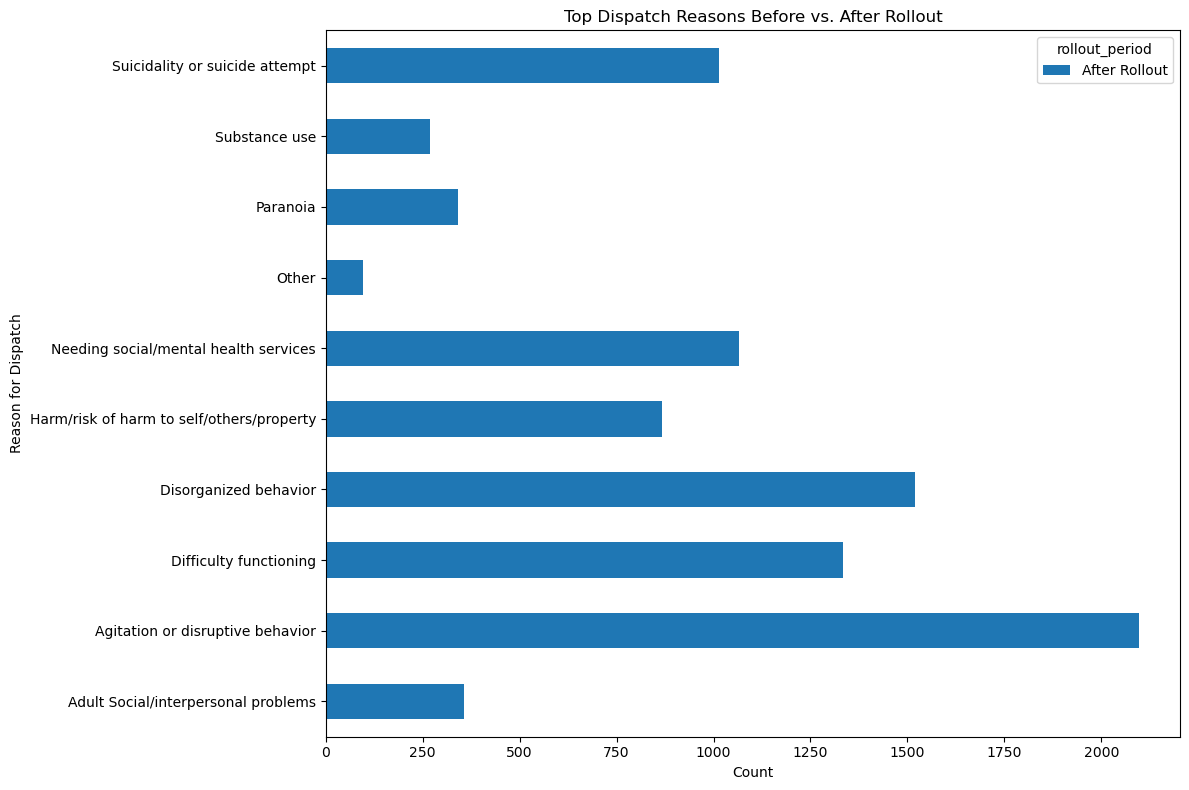

In [88]:
if "reason_for_dispatch" in reasons_long_clean.columns and "rollout_period" in reasons_long_clean.columns:
    top_reason_names = (
        reasons_long_clean["reason_for_dispatch"]
        .value_counts()
        .head(10)
        .index
    )
    
    reason_subset = reasons_long_clean[
        reasons_long_clean["reason_for_dispatch"].isin(top_reason_names)
    ]
    
    reason_rollout_counts = pd.crosstab(
        reason_subset["reason_for_dispatch"],
        reason_subset["rollout_period"]
    )
    
    reason_rollout_counts.plot(kind="barh", figsize=(12, 8))
    plt.title("Top Dispatch Reasons Before vs. After Rollout")
    plt.xlabel("Count")
    plt.ylabel("Reason for Dispatch")
    save_graph("top_reasons_before_after_rollout.png")
else:
    print("reason_for_dispatch or rollout_period column not found.")

## 16. Disposition Counts

This graph shows the most common MCSLC dispositions.

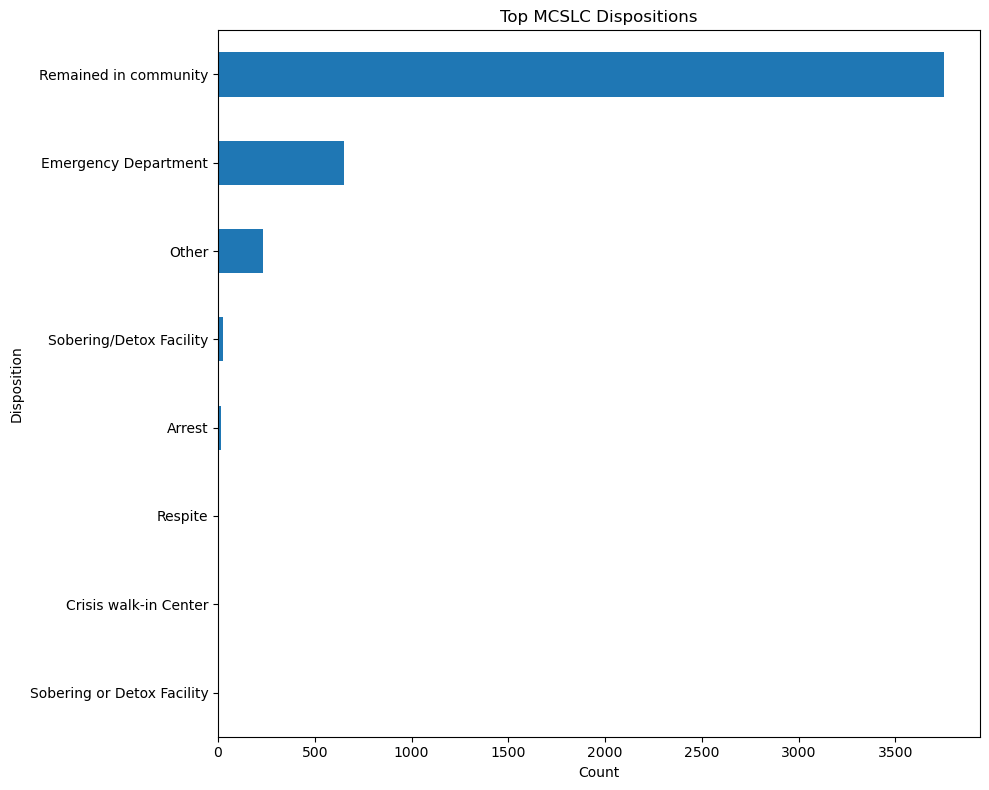

In [89]:
if "disposition" in mcslc_clean.columns:
    disposition_counts = (
        mcslc_clean["disposition"]
        .value_counts()
        .head(15)
        .sort_values()
    )
    
    plt.figure(figsize=(10, 8))
    disposition_counts.plot(kind="barh")
    plt.title("Top MCSLC Dispositions")
    plt.xlabel("Count")
    plt.ylabel("Disposition")
    save_graph("top_mcslc_dispositions.png")
else:
    print("disposition column not found.")

## 17. Dispositions by Rollout Period

This graph compares MCSLC dispositions before and after rollout.

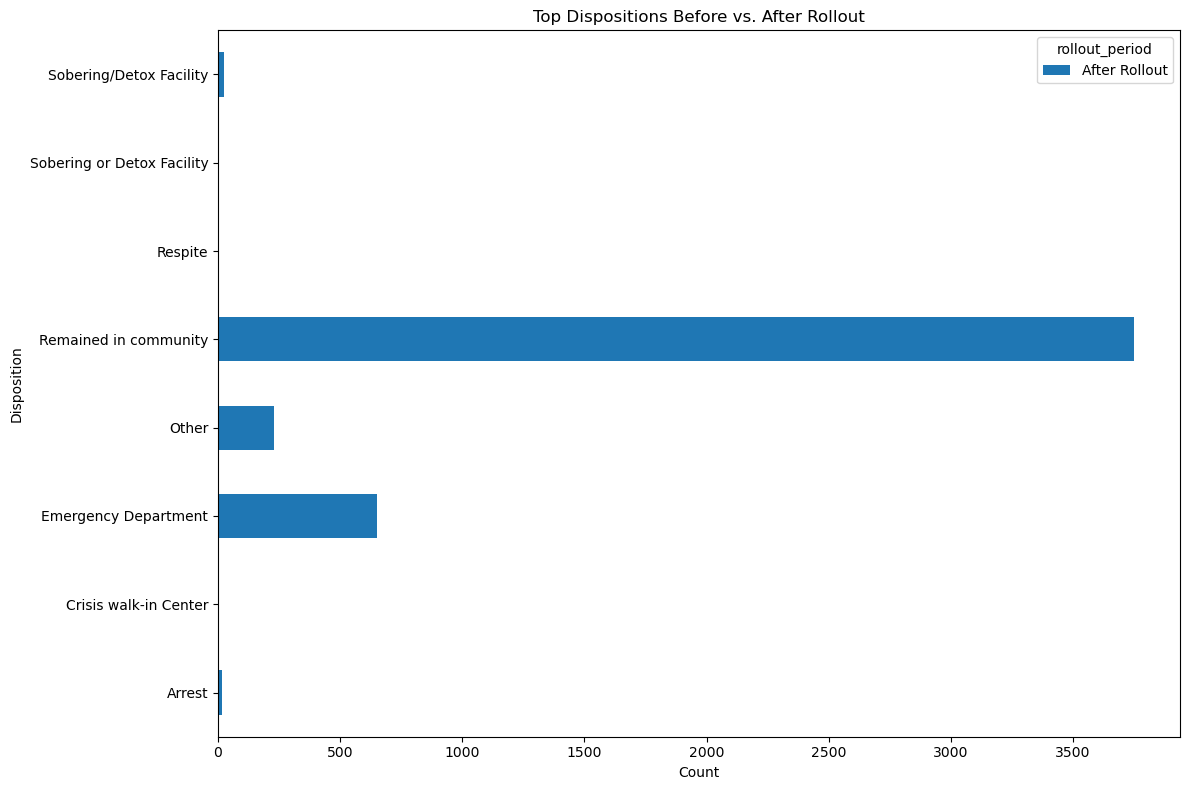

In [90]:
if "disposition" in mcslc_clean.columns and "rollout_period" in mcslc_clean.columns:
    top_dispositions = (
        mcslc_clean["disposition"]
        .value_counts()
        .head(10)
        .index
    )
    
    disposition_subset = mcslc_clean[
        mcslc_clean["disposition"].isin(top_dispositions)
    ]
    
    disposition_rollout_counts = pd.crosstab(
        disposition_subset["disposition"],
        disposition_subset["rollout_period"]
    )
    
    disposition_rollout_counts.plot(kind="barh", figsize=(12, 8))
    plt.title("Top Dispositions Before vs. After Rollout")
    plt.xlabel("Count")
    plt.ylabel("Disposition")
    save_graph("top_dispositions_before_after_rollout.png")
else:
    print("disposition or rollout_period column not found.")

## 18. Endpoint of Dispatch Counts

This graph shows the most common endpoints of dispatch.

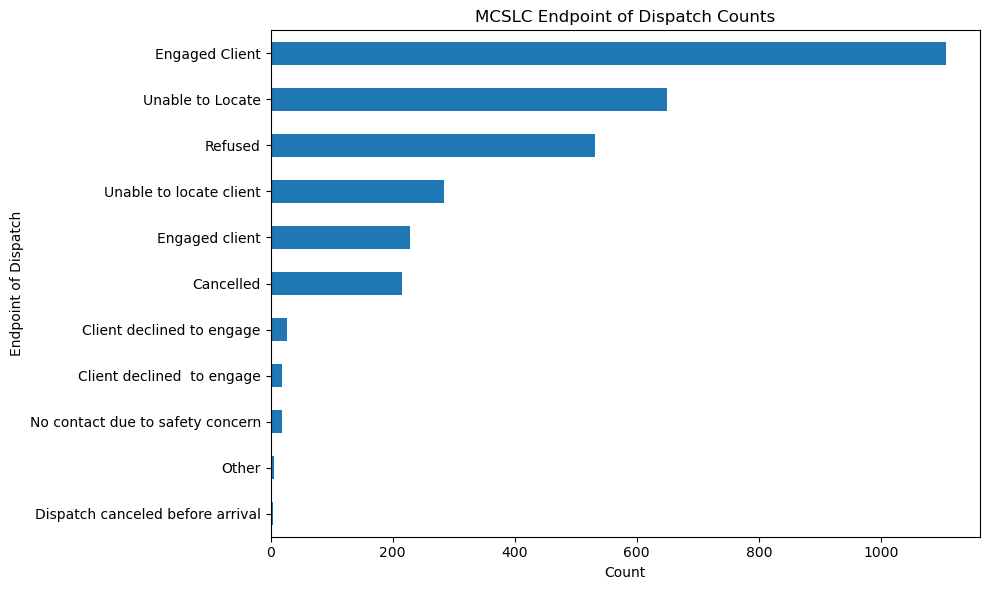

In [91]:
if "end_point_of_dispatch" in mcslc_clean.columns:
    endpoint_counts = (
        mcslc_clean["end_point_of_dispatch"]
        .value_counts()
        .sort_values()
    )
    
    plt.figure(figsize=(10, 6))
    endpoint_counts.plot(kind="barh")
    plt.title("MCSLC Endpoint of Dispatch Counts")
    plt.xlabel("Count")
    plt.ylabel("Endpoint of Dispatch")
    save_graph("endpoint_of_dispatch_counts.png")
else:
    print("end_point_of_dispatch column not found.")

## 19. Endpoint of Dispatch by Rollout Period

This graph compares dispatch endpoints before and after rollout.

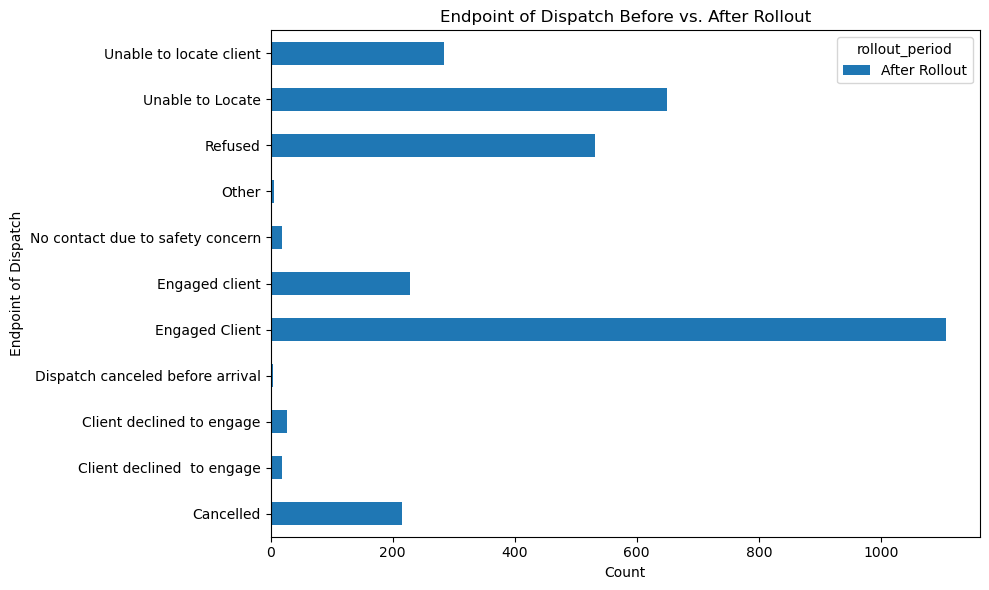

In [92]:
if "end_point_of_dispatch" in mcslc_clean.columns and "rollout_period" in mcslc_clean.columns:
    endpoint_rollout_counts = pd.crosstab(
        mcslc_clean["end_point_of_dispatch"],
        mcslc_clean["rollout_period"]
    )
    
    endpoint_rollout_counts.plot(kind="barh", figsize=(10, 6))
    plt.title("Endpoint of Dispatch Before vs. After Rollout")
    plt.xlabel("Count")
    plt.ylabel("Endpoint of Dispatch")
    save_graph("endpoint_of_dispatch_before_after_rollout.png")
else:
    print("end_point_of_dispatch or rollout_period column not found.")

## 20. SPD Relevant Initial Call Types

This graph shows the most common initial call types among relevant SPD calls.

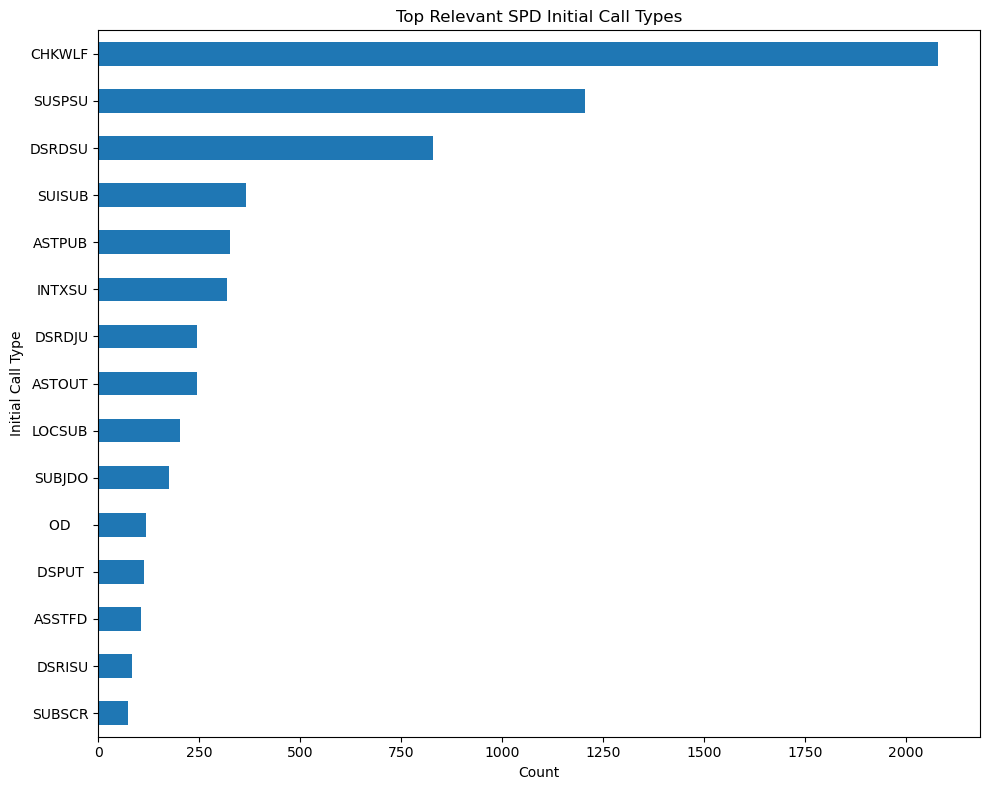

In [93]:
if "initial_call_type" in spd_relevant.columns:
    spd_initial_counts = (
        spd_relevant["initial_call_type"]
        .value_counts()
        .head(15)
        .sort_values()
    )
    
    plt.figure(figsize=(10, 8))
    spd_initial_counts.plot(kind="barh")
    plt.title("Top Relevant SPD Initial Call Types")
    plt.xlabel("Count")
    plt.ylabel("Initial Call Type")
    save_graph("top_relevant_spd_initial_call_types.png")
else:
    print("initial_call_type column not found.")

## 21. SPD Relevant Final Call Types

This graph shows the most common final call types among relevant SPD calls.

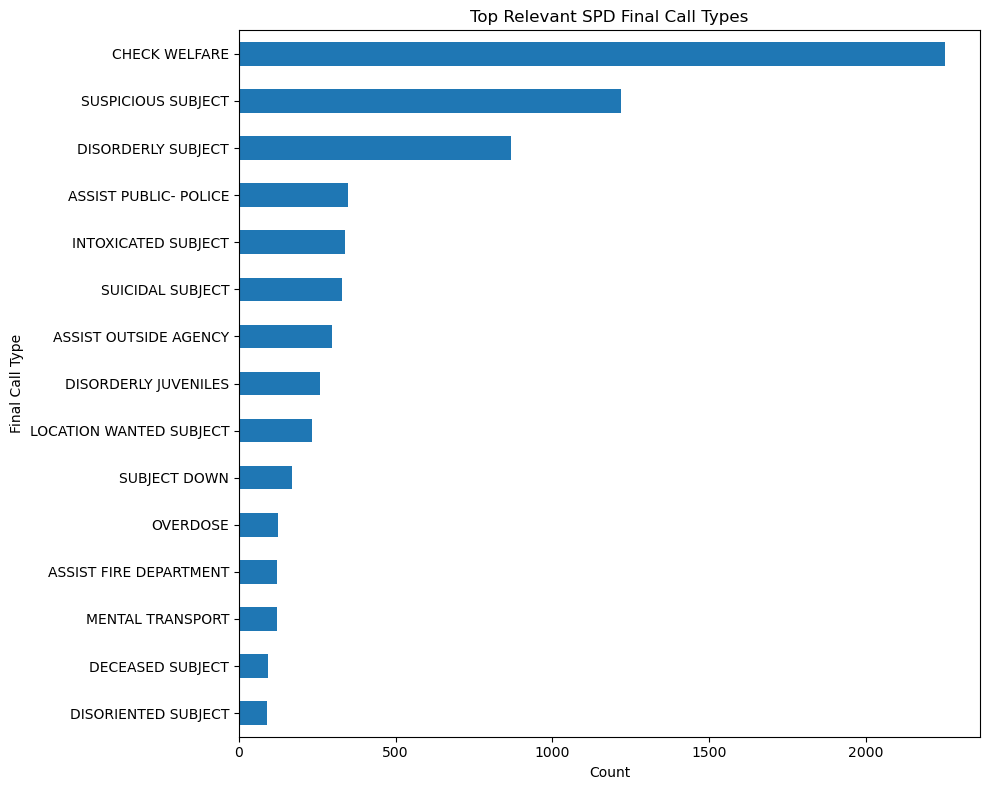

In [94]:
if "final_call_type" in spd_relevant.columns:
    spd_final_counts = (
        spd_relevant["final_call_type"]
        .value_counts()
        .head(15)
        .sort_values()
    )
    
    plt.figure(figsize=(10, 8))
    spd_final_counts.plot(kind="barh")
    plt.title("Top Relevant SPD Final Call Types")
    plt.xlabel("Count")
    plt.ylabel("Final Call Type")
    save_graph("top_relevant_spd_final_call_types.png")
else:
    print("final_call_type column not found.")

## 22. SPD Relevant Call Priority

This graph shows priority levels among relevant SPD calls.

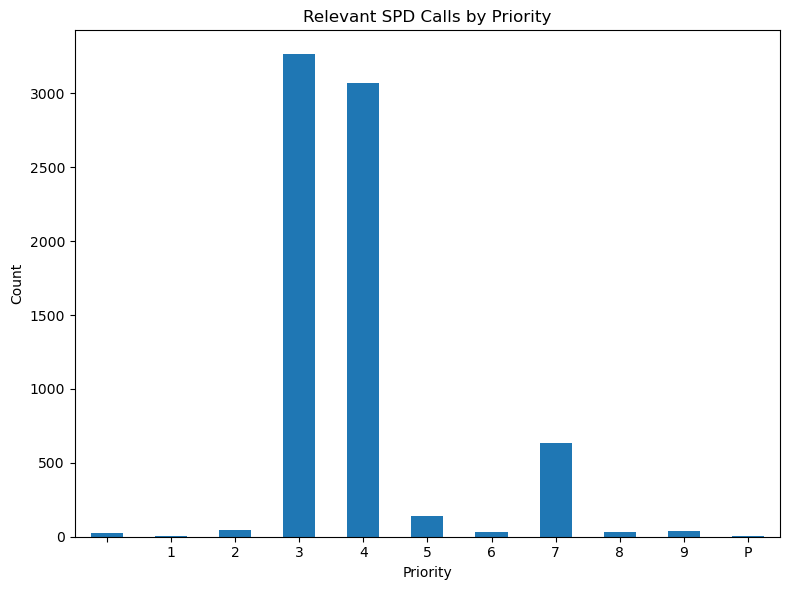

In [95]:
if "priority" in spd_relevant.columns:
    spd_priority_counts = (
        spd_relevant["priority"]
        .value_counts()
        .sort_index()
    )
    
    plt.figure(figsize=(8, 6))
    spd_priority_counts.plot(kind="bar")
    plt.title("Relevant SPD Calls by Priority")
    plt.xlabel("Priority")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    save_graph("relevant_spd_calls_by_priority.png")
else:
    print("priority column not found.")

## 23. SPD Responding Agency Counts

This graph shows the responding agencies among relevant SPD calls.

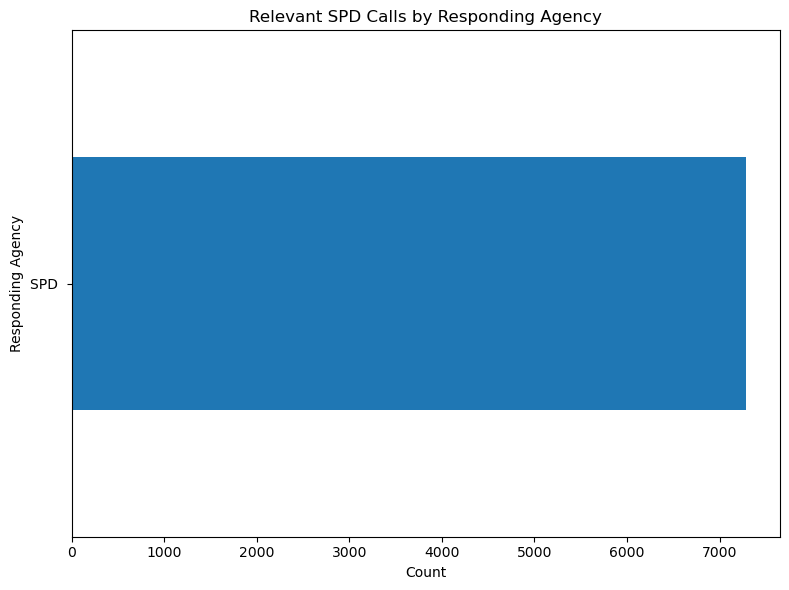

In [96]:
if "responding_agency" in spd_relevant.columns:
    spd_agency_counts = (
        spd_relevant["responding_agency"]
        .value_counts()
        .sort_values()
    )
    
    plt.figure(figsize=(8, 6))
    spd_agency_counts.plot(kind="barh")
    plt.title("Relevant SPD Calls by Responding Agency")
    plt.xlabel("Count")
    plt.ylabel("Responding Agency")
    save_graph("relevant_spd_calls_by_responding_agency.png")
else:
    print("responding_agency column not found.")

## 24. Final Graphing Notes

This notebook created the main visualizations for the project.